In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scanpy as sc

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from umap import UMAP

In [2]:
# outfigdir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/results_v1astro/'
out_adata = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/superdupermegaRNA_hasraw_cheng22_astro_v2.h5ad'
adata = sc.read("/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/superdupermegaRNA_hasraw_cheng22_astro.h5ad")
adata

AnnData object with n_obs × n_vars = 19330 × 16340
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'
    layers: 'norm'

In [3]:
def streamline_age(age):
    """
    """
    tags = age.split('_')
    age = tags[0]
    
    if len(tags) == 1:
        return age, "NR"
    elif len(tags) == 2:
        return age, tags[1].upper()
    
adata.obs['Time'] = adata.obs['Age'].apply(lambda x: streamline_age(x)[0])
adata.obs['Light'] = adata.obs['Age'].apply(lambda x: streamline_age(x)[1])

In [4]:
exp_conds = ['P28', 'P28_dr', 'P38', 'P38_dr']
adata = adata[adata.obs['Age'].isin(exp_conds)]
adata

View of AnnData object with n_obs × n_vars = 7697 × 16340
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'Time', 'Light'
    var: 'feature_types'
    layers: 'norm'

In [5]:
# remove mitocondria genes
adata = adata[:,~adata.var.index.str.contains(r'^mt-')]

# remove sex genes
sex_genes = ["Xist", "Uty", "Eif2s3y", "Kdm5d", "Ddx3y"]
adata = adata[:,[g for g in adata.var.index if g not in sex_genes]]

# filter genes
cond = np.ravel((adata.X>0).sum(axis=0)) > 10 # expressed in more than 10 cells
adata = adata[:,cond].copy()
# genes = adata.var.index.values

adata

AnnData object with n_obs × n_vars = 7697 × 15573
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'Time', 'Light'
    var: 'feature_types'
    layers: 'norm'

In [6]:
%%time
mat = np.array(np.log2(adata.layers['norm']+1))
pcs = PCA(n_components=30).fit_transform(mat)
ucs = UMAP(n_components=2).fit_transform(pcs)
pcs.shape, ucs.shape
# mat.shape

CPU times: user 11min 41s, sys: 7.15 s, total: 11min 48s
Wall time: 49 s


((7697, 30), (7697, 2))

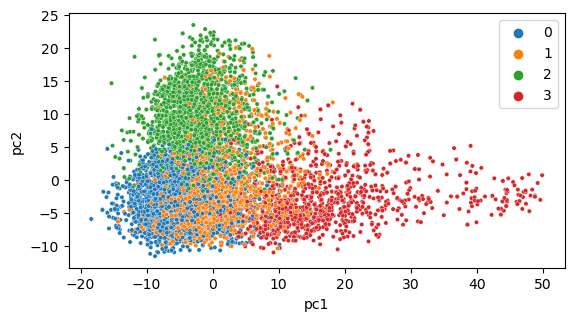

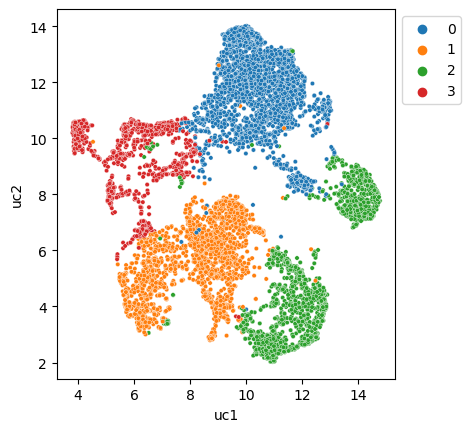

In [7]:
# To store results under a specific name
np.random.seed(0)

res = 0.2
pcs_key = 'pc_astro'
neighbors_key = 'ngbr_astro'
clusters_key = 'curated_cluster'

adata.obsm[pcs_key] = pcs
sc.pp.neighbors(adata, n_neighbors=30, use_rep=pcs_key, key_added=neighbors_key)
sc.tl.leiden(adata, resolution=res, key_added=clusters_key, neighbors_key=neighbors_key)

dfplot = adata.obs
dfplot['pc1'] = pcs[:,0]
dfplot['pc2'] = pcs[:,1]
dfplot['uc1'] = ucs[:,0]
dfplot['uc2'] = ucs[:,1]

fig, ax = plt.subplots()
sns.scatterplot(data=dfplot.sample(frac=1), x='pc1', y='pc2', hue=clusters_key, s=10, ax=ax)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

fig, ax = plt.subplots()
sns.scatterplot(data=dfplot, x='uc1', y='uc2', hue=clusters_key, s=10, ax=ax)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

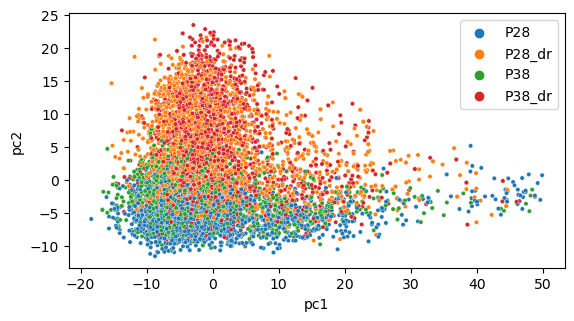

In [8]:
fig, ax = plt.subplots()
sns.scatterplot(data=dfplot.sample(frac=1), x='pc1', y='pc2', hue='Age', s=10, ax=ax)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

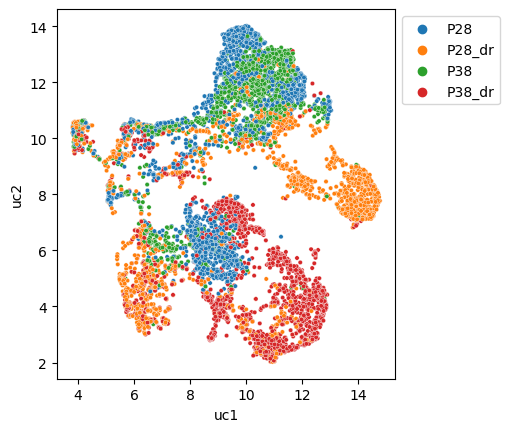

In [9]:
fig, ax = plt.subplots()
sns.scatterplot(data=dfplot.sample(frac=1), x='uc1', y='uc2', hue='Age', s=10, ax=ax)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

In [11]:
# fig, ax = plt.subplots()
# sns.scatterplot(data=dfplot.sample(frac=1), x='1', y='pc2', hue='Age', s=10, ax=ax)
# ax.set_aspect('equal')
# ax.legend(bbox_to_anchor=(1,1))
# plt.show()

In [12]:
counts = dfplot.groupby(['Age', 'curated_cluster']).size().unstack().T
counts

Age,P28,P28_dr,P38,P38_dr
curated_cluster,,,,
0,1035,515,1101,18
1,800,440,199,828
2,1,710,6,1060
3,332,295,179,178


In [13]:
freqs = counts.divide(counts.sum(axis=1), axis=0)
freqs = counts/counts.sum()
freqs.sum()

Age
P28       1.0
P28_dr    1.0
P38       1.0
P38_dr    1.0
dtype: float64

<Axes: xlabel='Age'>

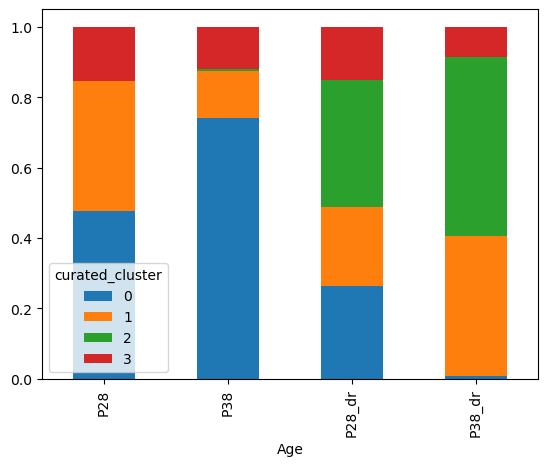

In [14]:
freqs[['P28', 'P38', 'P28_dr', 'P38_dr']].T.plot.bar(stacked=True)

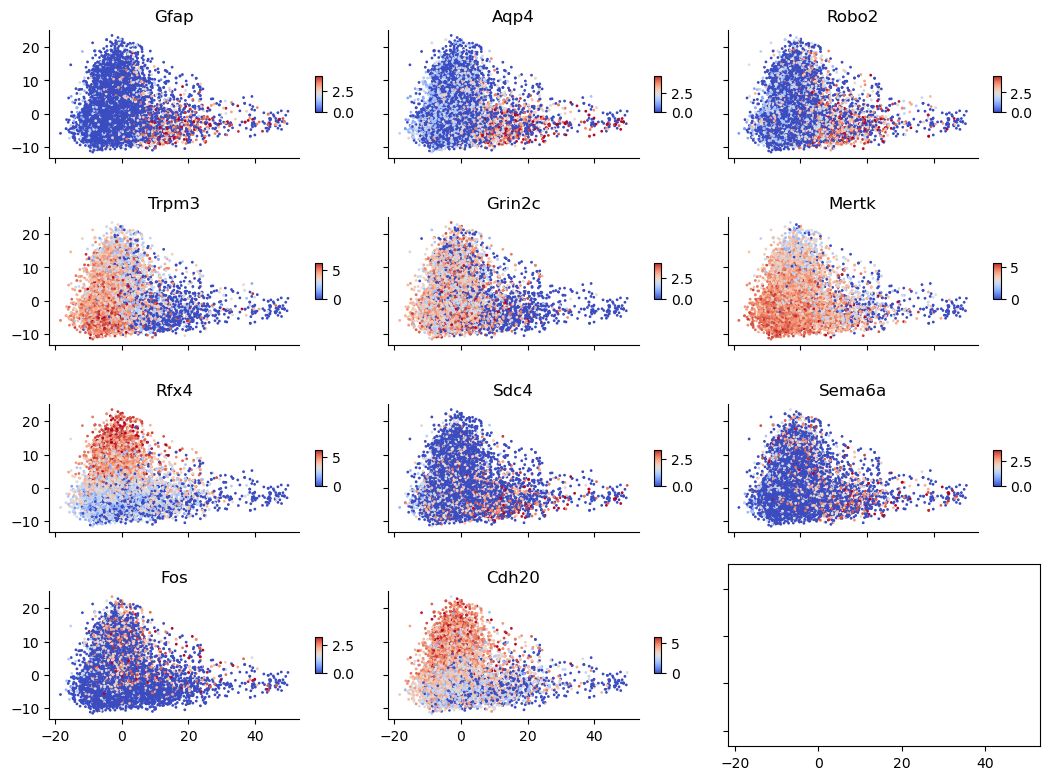

In [15]:
gns = [
    'Gfap', 'Aqp4', 'Robo2', 
    'Trpm3','Grin2c', 'Mertk', 
    
    'Rfx4', 'Sdc4', 'Sema6a',
    'Fos', 
    
    'Cdh20',
]

n = len(gns)
nx = 3
ny = int((n+nx-1)/nx)

fig, axs = plt.subplots(ny,nx,figsize=(3.5*nx,2*ny), sharex=True, sharey=True)
for gn, ax in zip(gns, axs.flat):
    gexp = np.array(np.log2(1+adata[:,gn].layers['norm'])).reshape(-1,)
    vmin = np.percentile(gexp,  0)
    vmax = np.percentile(gexp, 99)
    g = ax.scatter(pcs[:,0], pcs[:,1], c=gexp, s=1, 
                cmap='coolwarm', vmin=vmin, vmax=vmax)
    ax.set_aspect('equal')
    ax.grid(False)
    sns.despine(ax=ax)
    ax.set_title(gn)
    fig.colorbar(g, shrink=0.2, aspect=5)
fig.tight_layout()

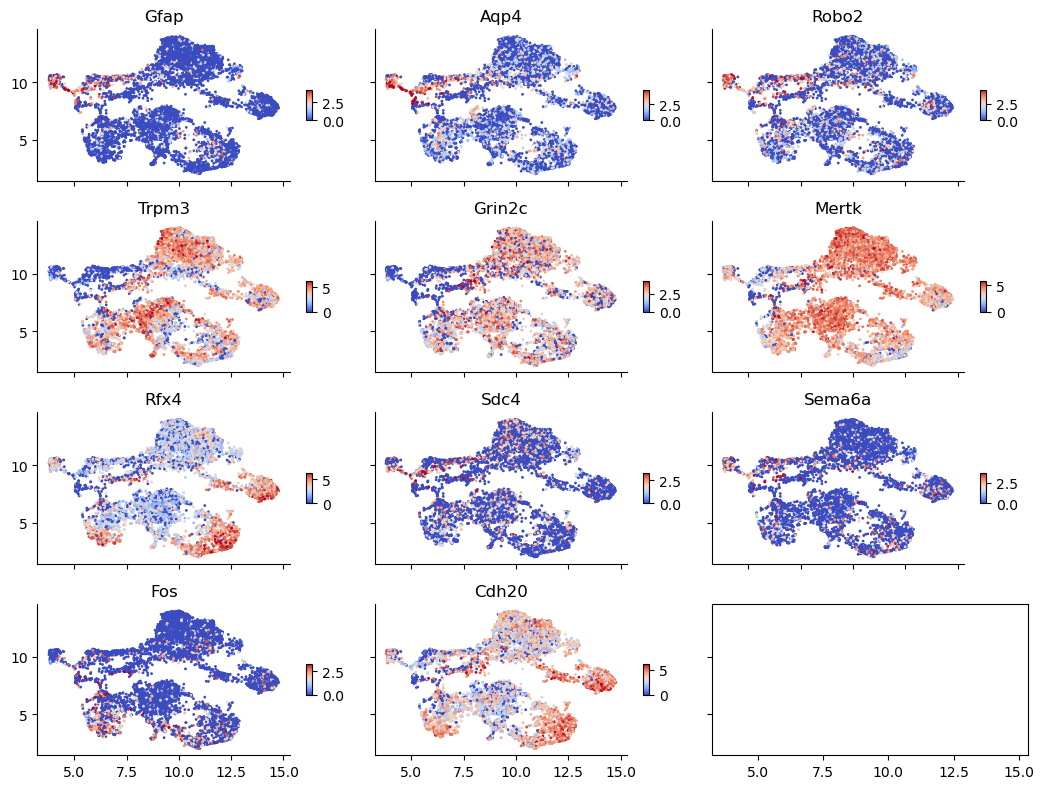

In [16]:
gns = [
    'Gfap', 'Aqp4', 'Robo2', 
    'Trpm3','Grin2c', 'Mertk', 
    
    'Rfx4', 'Sdc4', 'Sema6a',
    'Fos',
    
    'Cdh20',
]

n = len(gns)
nx = 3
ny = int((n+nx-1)/nx)

fig, axs = plt.subplots(ny,nx,figsize=(3.5*nx,2*ny), sharex=True, sharey=True)
for gn, ax in zip(gns, axs.flat):
    gexp = np.array(np.log2(1+adata[:,gn].layers['norm'])).reshape(-1,)
    vmin = np.percentile(gexp,  0)
    vmax = np.percentile(gexp, 99)
    g = ax.scatter(ucs[:,0], ucs[:,1], c=gexp, s=1, 
                cmap='coolwarm', vmin=vmin, vmax=vmax)
    # ax.set_aspect('equal')
    ax.grid(False)
    sns.despine(ax=ax)
    ax.set_title(gn)
    fig.colorbar(g, shrink=0.2, aspect=5)
fig.tight_layout()

In [ ]:
# export
# adata.write(out_adata)